In [1]:
!pip install diffusers transformers accelerate controlnet-aux
!pip install git+https://github.com/openai/CLIP.git
!pip install segment-anything

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 6.5 MB/s eta 0:00:0000:01
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_qgxxq6s
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_qgxxq6s
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=2645075399116e33193600a4bdc1dc907dd706c6f4c3b4b234c96053613a5a25
  Stored in directory: /tmp/pip-ephem-wheel-cache-d0qoy1cu/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from diffusers import UniPCMultistepScheduler
from transformers import pipeline as hf_pipeline
from PIL import Image
import requests
from io import BytesIO
import torch
import numpy as np

print("All imports done!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


All imports done!


In [3]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth",
    torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

pipe.scheduler = UniPCMultistepScheduler.from_config(
    pipe.scheduler.config
)
pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing()

print("Pipeline loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pipeline loaded!


In [4]:
depth_estimator = hf_pipeline(
    "depth-estimation",
    model="LiheYoung/depth-anything-base-hf"
)

print("Depth estimator loaded!")

config.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Depth estimator loaded!


In [5]:
!pip install diffusers transformers accelerate controlnet-aux xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 33.3 MB/s eta 0:00:00a 0:00:01


Image loaded!


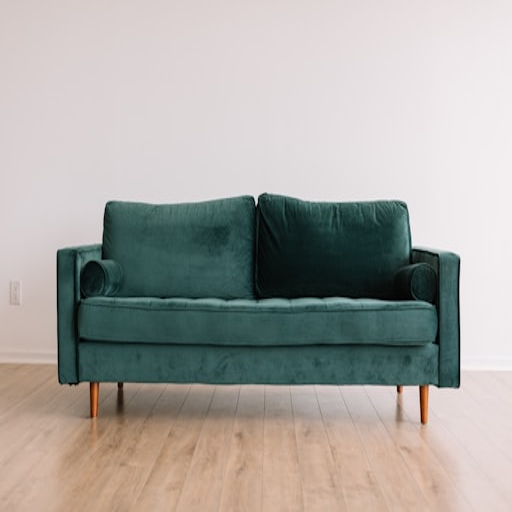

In [6]:
url = "https://images.unsplash.com/photo-1555041469-a586c61ea9bc?w=512"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
image = Image.open(BytesIO(response.content)).convert("RGB")
image = image.resize((512, 512))

print("Image loaded!")
image

Depth map ready!


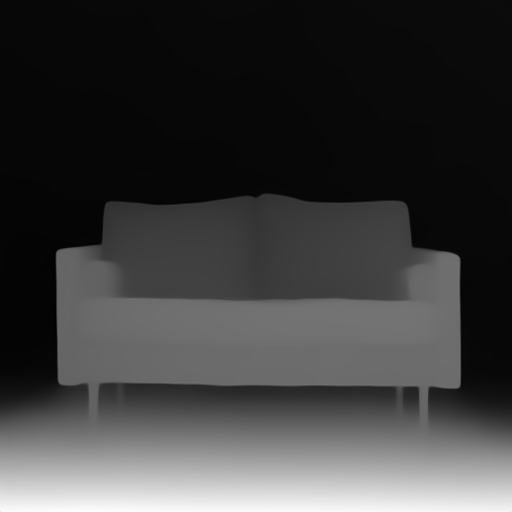

In [7]:
depth_result = depth_estimator(image)
depth_map = depth_result["depth"].resize((512, 512))

print("Depth map ready!")
depth_map

  0%|          | 0/20 [00:00<?, ?it/s]

Generation complete!


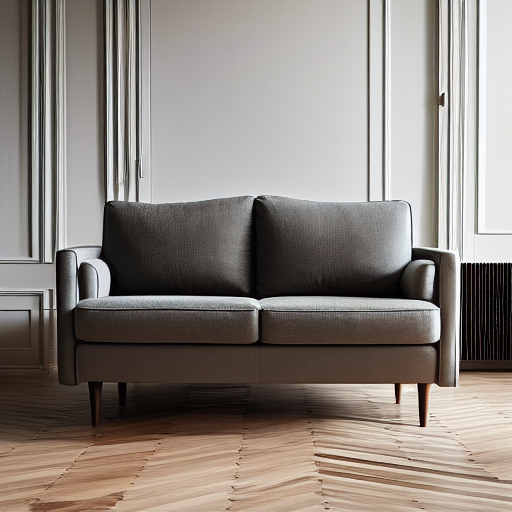

In [8]:
result = pipe(
    prompt="a modern scandinavian living room, \
            warm lighting, minimalist furniture, \
            hardwood floors, photorealistic, \
            interior design magazine, 8k",
    
    negative_prompt="ugly, blurry, bad proportions, \
                     unrealistic, cartoon, drawing, \
                     dark, gloomy",
    
    image=depth_map,
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

print("Generation complete!")
result

In [9]:
styles = [
    "a modern scandinavian living room, warm lighting, minimalist, photorealistic",
    "a luxurious royal living room, gold accents, velvet furniture, photorealistic",
    "an industrial loft, exposed brick walls, metal fixtures, photorealistic",
    "a bohemian cozy room, warm earth tones, plants everywhere, photorealistic"
]

results = []

for style in styles:
    output = pipe(
        prompt=style,
        negative_prompt="ugly, blurry, unrealistic, cartoon",
        image=depth_map,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]
    results.append(output)
    print(f"Generated: {style[:40]}...")

print("All styles generated!")

  0%|          | 0/20 [00:00<?, ?it/s]

Generated: a modern scandinavian living room, warm ...


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: a luxurious royal living room, gold acce...


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: an industrial loft, exposed brick walls,...


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: a bohemian cozy room, warm earth tones, ...
All styles generated!


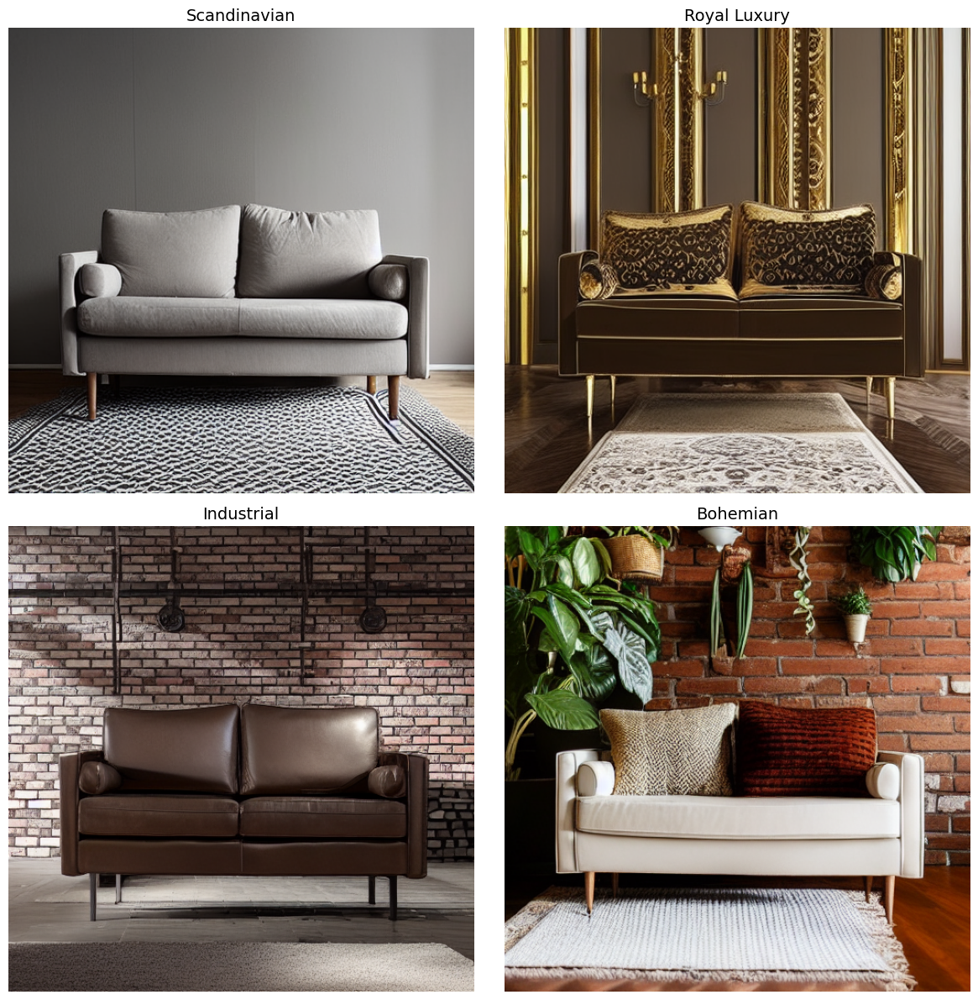

Saved!


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
style_names = ["Scandinavian", "Royal Luxury", "Industrial", "Bohemian"]

for idx, (ax, result, name) in enumerate(zip(axes.flatten(), results, style_names)):
    ax.imshow(result)
    ax.set_title(name, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.savefig("style_comparison.png")
plt.show()
print("Saved!")

In [11]:
print(pipe)       # Should show StableDiffusionControlNetPipeline
print(depth_map)  # Should show PIL Image info
print(image)      # Should show PIL Image info

StableDiffusionControlNetPipeline {
  "_class_name": "StableDiffusionControlNetPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "controlnet": [
    "diffusers",
    "ControlNetModel"
  ],
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "UniPCMultistepScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

<PIL.Image.Image image mode=L size=512x512 at 0x7FAAC43701A0>
<PIL.Image.Image image mode=RGB size=512x512 at 0x7FAAC42666F0>


In [12]:
!pip install segment-anything
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

from segment_anything import SamPredictor, sam_model_registry
import numpy as np

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cuda")
predictor = SamPredictor(sam)

print("SAM loaded!")

SAM loaded!


In [13]:
import numpy as np

# Convert image to numpy array
image_np = np.array(image)

# MUST set image before predicting
predictor.set_image(image_np)

# Multiple click points to cover full sofa
click_points = np.array([
    [256, 250],
    [256, 300],
    [256, 350],
])
click_labels = np.array([1, 1, 1])

masks, scores, logits = predictor.predict(
    point_coords=click_points,
    point_labels=click_labels,
    multimask_output=False
)

print(f"Mask generated! Confidence: {scores[0]:.3f}")

Mask generated! Confidence: 0.944


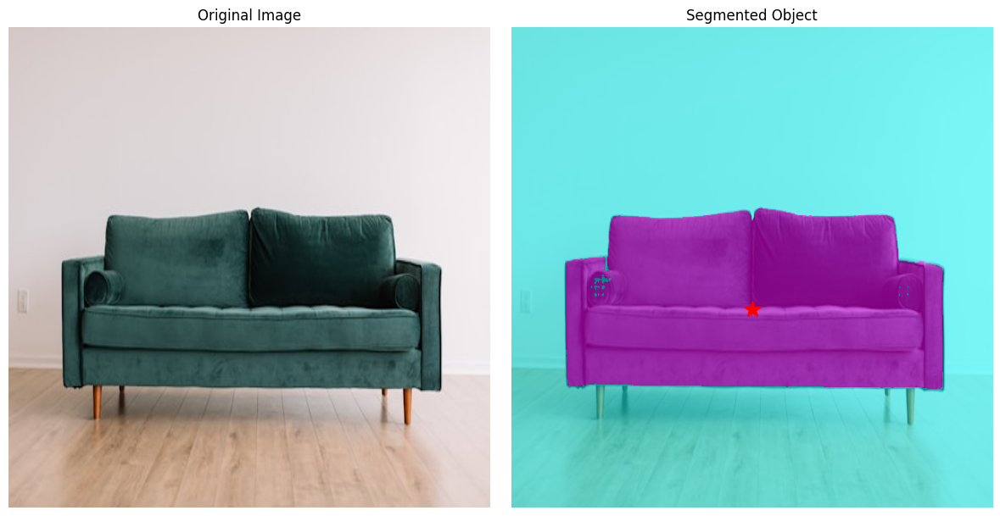

Segmentation visualized!


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Image with mask overlay
axes[1].imshow(image)
axes[1].imshow(masks[0], alpha=0.5, cmap="cool")
axes[1].plot(256, 300, "r*", markersize=15)  # Show click point
axes[1].set_title("Segmented Object")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("sam_segmentation.png")
plt.show()
print("Segmentation visualized!")

  0%|          | 0/20 [00:00<?, ?it/s]

Done!


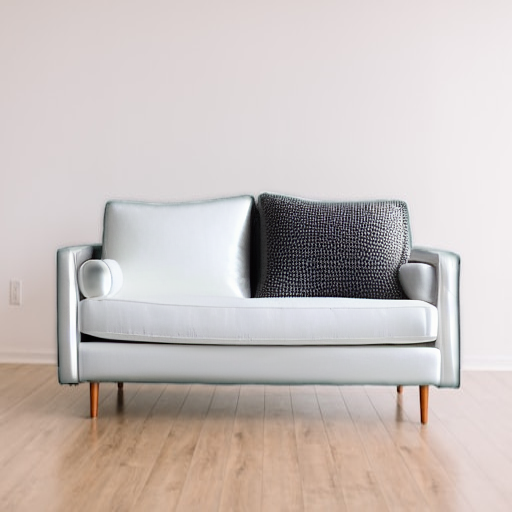

In [15]:
from PIL import Image, ImageFilter
import numpy as np

mask_image = Image.fromarray((masks[0] * 255).astype(np.uint8))
mask_blurred = mask_image.filter(ImageFilter.GaussianBlur(radius=3))

depth_result = depth_estimator(image)
depth_map = depth_result["depth"].resize((512, 512))

result_masked = pipe(
    prompt="a clean modern white fabric sofa, \
            scandinavian style, wooden legs, \
            photorealistic, interior design magazine",
    negative_prompt="ugly, blurry, unrealistic, \
                     cartoon, gold, gaudy, shiny",
    image=depth_map,
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

result_composite = Image.composite(result_masked, image, mask_blurred)
print("Done!")
result_composite

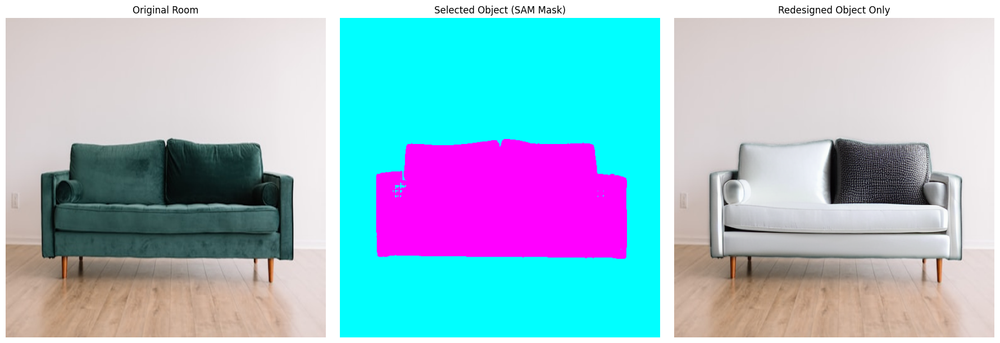

Saved!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original Room")
axes[0].axis("off")

axes[1].imshow(masks[0], cmap="cool")
axes[1].set_title("Selected Object (SAM Mask)")
axes[1].axis("off")

axes[2].imshow(result_composite)
axes[2].set_title("Redesigned Object Only")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("object_redesign.png")
plt.show()
print("Saved!")

In [17]:
!pip install git+https://github.com/openai/CLIP.git

import clip
import torch
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

print(f"CLIP loaded on {device}!")

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-nt_xs0vb
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-nt_xs0vb
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 203MiB/s]


CLIP loaded on cuda!


In [18]:
def encode_image_style(img):
    """Takes a PIL image, returns its CLIP embedding"""
    image_tensor = clip_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = clip_model.encode_image(image_tensor)
    return embedding.cpu()

# Test it on your existing result
embedding = encode_image_style(result_composite)
print(f"Style embedding shape: {embedding.shape}")
print("Encoder working!")

Style embedding shape: torch.Size([1, 512])
Encoder working!


In [19]:
# This simulates a user liking and disliking certain styles
liked_images = []
disliked_images = []

def like_image(img):
    liked_images.append(encode_image_style(img))
    print(f"👍 Liked! Total liked: {len(liked_images)}")

def dislike_image(img):
    disliked_images.append(encode_image_style(img))
    print(f"👎 Disliked! Total disliked: {len(disliked_images)}")

def get_style_profile():
    """Builds user style profile from liked/disliked images"""
    if not liked_images:
        return None
    
    liked_mean = torch.stack(liked_images).mean(0)
    
    if disliked_images:
        disliked_mean = torch.stack(disliked_images).mean(0)
        # Pull toward liked, push away from disliked
        profile = liked_mean - (disliked_mean * 0.3)
    else:
        profile = liked_mean
    
    return profile

print("Preference system ready!")

Preference system ready!


In [20]:
# Generate 4 different styles to react to
test_styles = [
    ("scandinavian", "modern scandinavian room, white walls, minimal, photorealistic"),
    ("industrial", "industrial loft, exposed brick, dark tones, photorealistic"),
    ("bohemian", "bohemian room, earth tones, plants, warm, photorealistic"),
    ("luxury", "luxury room, gold accents, velvet, chandeliers, photorealistic"),
]

generated_styles = {}

for name, prompt in test_styles:
    output = pipe(
        prompt=prompt,
        negative_prompt="ugly, blurry, cartoon, unrealistic",
        image=depth_map,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]
    generated_styles[name] = output
    print(f"Generated: {name}")

print("All styles ready!")

  0%|          | 0/20 [00:00<?, ?it/s]

Generated: scandinavian


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: industrial


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: bohemian


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: luxury
All styles ready!


In [21]:
# Simulate user preferences
# User likes clean minimal styles
like_image(generated_styles["scandinavian"])
like_image(generated_styles["bohemian"])

# User dislikes dark heavy styles  
dislike_image(generated_styles["industrial"])
dislike_image(generated_styles["luxury"])

# Build their style profile
profile = get_style_profile()
print(f"Style profile shape: {profile.shape}")
print("User taste profile built!")

👍 Liked! Total liked: 1
👍 Liked! Total liked: 2
👎 Disliked! Total disliked: 1
👎 Disliked! Total disliked: 2
Style profile shape: torch.Size([1, 512])
User taste profile built!


In [22]:
# Define style anchors
style_anchors = [
    "scandinavian minimalist interior",
    "industrial dark loft interior",
    "bohemian warm cozy interior",
    "luxury royal opulent interior",
    "modern clean contemporary interior",
    "rustic farmhouse interior",
    "japandi zen minimal interior"
]

# Generate 4 different styles to react to
test_styles = [
    ("scandinavian", "modern scandinavian room, white walls, minimal, photorealistic"),
    ("industrial", "industrial loft, exposed brick, dark tones, photorealistic"),
    ("bohemian", "bohemian room, earth tones, plants, warm, photorealistic"),
    ("luxury", "luxury room, gold accents, velvet, chandeliers, photorealistic"),
]

generated_styles = {}

for name, prompt in test_styles:
    output = pipe(
        prompt=prompt,
        negative_prompt="ugly, blurry, cartoon, unrealistic",
        image=depth_map,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]
    generated_styles[name] = output
    print(f"Generated: {name}")

print("All styles ready!")

# ---- THIS PART WAS MISSING ----
# Encode style anchors into CLIP text embeddings
text_tokens = clip.tokenize(style_anchors).to(device)
with torch.no_grad():
    text_embeddings = clip_model.encode_text(text_tokens).cpu()

# Fix tensor shapes
profile_flat = profile.squeeze().float()
text_embeddings = text_embeddings.float()

# Find closest style anchor to user profile
similarities = torch.cosine_similarity(
    profile_flat.unsqueeze(0).expand_as(text_embeddings),
    text_embeddings
)

best_match_idx = similarities.argmax().item()
best_style = style_anchors[best_match_idx]

print(f"Your taste profile matches: '{best_style}'")
print(f"Similarity scores: {similarities.tolist()}")

  0%|          | 0/20 [00:00<?, ?it/s]

Generated: scandinavian


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: industrial


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: bohemian


  0%|          | 0/20 [00:00<?, ?it/s]

Generated: luxury
All styles ready!
Your taste profile matches: 'scandinavian minimalist interior'
Similarity scores: [0.27006596326828003, 0.2034902572631836, 0.2642357349395752, 0.20246954262256622, 0.21810635924339294, 0.22904178500175476, 0.22552326321601868]


  0%|          | 0/20 [00:00<?, ?it/s]

Generated with personalized prompt: a scandinavian minimalist interior,                         photorealistic,                         interior design magazine, 8k,                         warm lighting


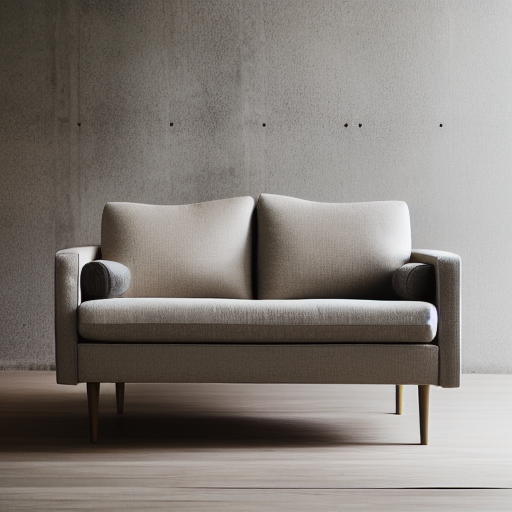

In [23]:
personalized_prompt = f"a {best_style}, \
                        photorealistic, \
                        interior design magazine, 8k, \
                        warm lighting"

personalized_result = pipe(
    prompt=personalized_prompt,
    negative_prompt="ugly, blurry, cartoon, unrealistic",
    image=depth_map,
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

print(f"Generated with personalized prompt: {personalized_prompt}")
personalized_result

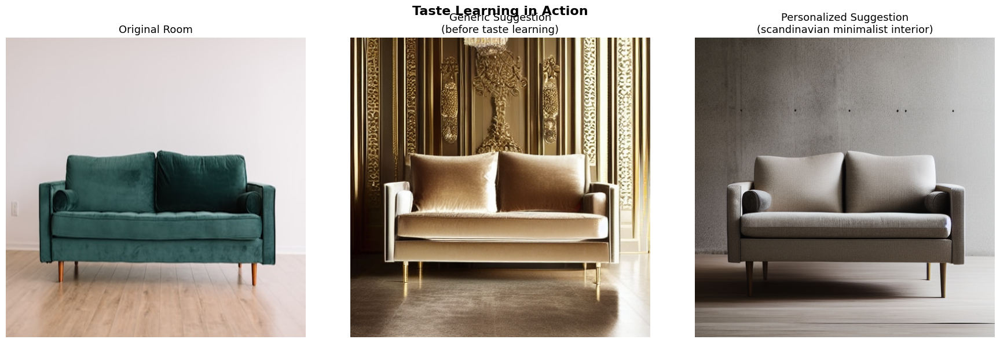

Saved!


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original Room", fontsize=13)
axes[0].axis("off")

axes[1].imshow(generated_styles["luxury"])
axes[1].set_title("Generic Suggestion\n(before taste learning)", fontsize=13)
axes[1].axis("off")

axes[2].imshow(personalized_result)
axes[2].set_title(f"Personalized Suggestion\n({best_style})", fontsize=13)
axes[2].axis("off")

plt.suptitle("Taste Learning in Action", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("taste_learning_demo.png")
plt.show()
print("Saved!")

In [25]:
from PIL import Image, ImageFilter
import numpy as np

# Style anchors must be defined before full_pipeline
style_anchors = [
    "scandinavian minimalist interior",
    "industrial dark loft interior",
    "bohemian warm cozy interior",
    "luxury royal opulent interior",
    "modern clean contemporary interior",
    "rustic farmhouse interior",
    "japandi zen minimal interior"
]

def full_pipeline(input_image, user_id="default",
                  click_point=None, base_prompt="a beautiful room"):

    print(f"Processing for user: {user_id}")

    # Step 1 — Resize input
    input_image = input_image.resize((512, 512))

    # Step 2 — Get depth map
    depth_result = depth_estimator(input_image)
    depth_map = depth_result["depth"].resize((512, 512))
    print("✅ Depth map generated")

    # Step 3 — Get style modifier from user profile
    if liked_images:
        profile = get_style_profile()
        profile_flat = profile.squeeze().float()
        text_tokens = clip.tokenize(style_anchors).to(device)
        with torch.no_grad():
            text_embeddings = clip_model.encode_text(
                               text_tokens).cpu().float()
        similarities = torch.cosine_similarity(
            profile_flat.unsqueeze(0).expand_as(text_embeddings),
            text_embeddings
        )
        style_modifier = style_anchors[similarities.argmax().item()]
        final_prompt = f"{base_prompt}, {style_modifier}, \
                        photorealistic, interior design magazine"
    else:
        final_prompt = f"{base_prompt}, photorealistic, \
                        interior design magazine"

    print(f"✅ Style prompt: {final_prompt}")

    # Step 4 — Optional object segmentation
    if click_point is not None:
        image_np = np.array(input_image)
        predictor.set_image(image_np)
        click_points = np.array([click_point])
        click_labels = np.array([1])
        masks, _, _ = predictor.predict(
            point_coords=click_points,
            point_labels=click_labels,
            multimask_output=False
        )
        mask_image = Image.fromarray(
                     (masks[0] * 255).astype(np.uint8))
        mask_blurred = mask_image.filter(
                       ImageFilter.GaussianBlur(radius=3))
        print("✅ Object segmented")
    else:
        mask_blurred = None
        print("✅ Full room mode (no object selected)")

    # Step 5 — Generate redesign
    result = pipe(
        prompt=final_prompt,
        negative_prompt="ugly, blurry, cartoon, unrealistic",
        image=depth_map,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]
    print("✅ Redesign generated")

    # Step 6 — Apply mask if object mode
    if mask_blurred is not None:
        result = Image.composite(result, input_image, mask_blurred)
        print("✅ Object composite applied")

    print("🎉 Pipeline complete!")
    return result

print("full_pipeline ready!")

full_pipeline ready!


=== TEST 1: Full Room ===
Processing for user: student_1
✅ Depth map generated
✅ Style prompt: same room with white walls,                  light grey sofa, wooden floor,                  bright natural lighting, minimal decor,                  no wood panels, open airy space,                  scandinavian apartment, scandinavian minimalist interior,                         photorealistic, interior design magazine
✅ Full room mode (no object selected)


  0%|          | 0/20 [00:00<?, ?it/s]

✅ Redesign generated
🎉 Pipeline complete!
=== TEST 2: Object Only ===
Processing for user: student_1
✅ Depth map generated
✅ Style prompt: a modern sofa, clean fabric,                  scandinavian style, wooden legs, scandinavian minimalist interior,                         photorealistic, interior design magazine
✅ Object segmented


  0%|          | 0/20 [00:00<?, ?it/s]

✅ Redesign generated
✅ Object composite applied
🎉 Pipeline complete!


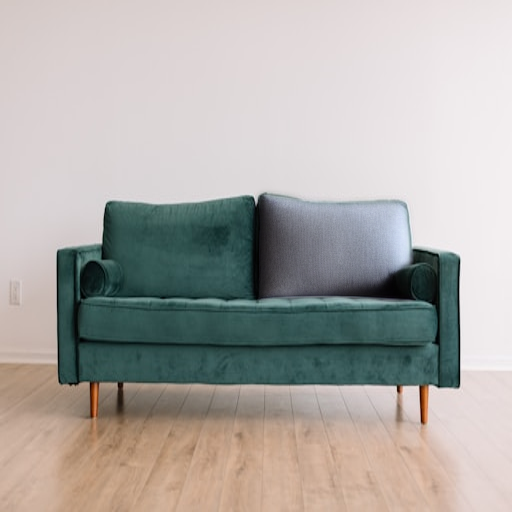

In [26]:
# Test 1 — Full room redesign with better prompt
print("=== TEST 1: Full Room ===")
result1 = full_pipeline(
    input_image=image,
    user_id="student_1",
    base_prompt="same room with white walls, \
                 light grey sofa, wooden floor, \
                 bright natural lighting, minimal decor, \
                 no wood panels, open airy space, \
                 scandinavian apartment"
)
result1
# Test 2 — Object only (separate cell)
print("=== TEST 2: Object Only ===")
result2 = full_pipeline(
    input_image=image,
    user_id="student_1",
    click_point=[256, 280],
    base_prompt="a modern sofa, clean fabric, \
                 scandinavian style, wooden legs"
)
result2

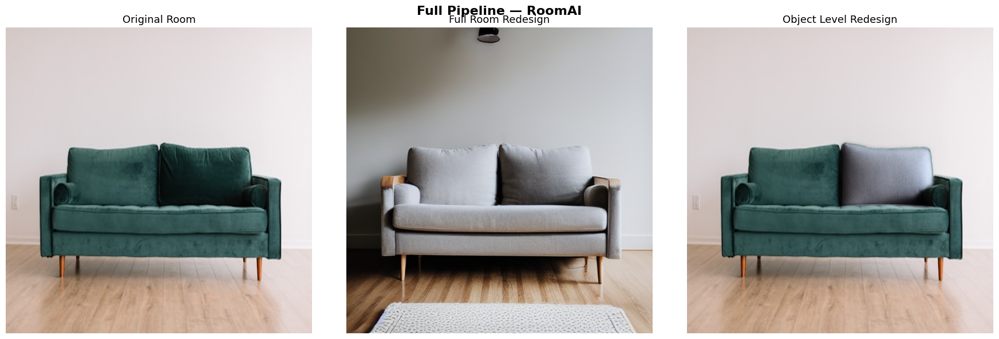

✅ Saved as final_pipeline_demo.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original Room", fontsize=13)
axes[0].axis("off")

axes[1].imshow(result1)
axes[1].set_title("Full Room Redesign", fontsize=13)
axes[1].axis("off")

axes[2].imshow(result2)
axes[2].set_title("Object Level Redesign", fontsize=13)
axes[2].axis("off")

plt.suptitle("Full Pipeline — RoomAI", 
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("final_pipeline_demo.png")
plt.show()
print("✅ Saved as final_pipeline_demo.png")

In [28]:
guidance_scales = [5.0, 7.5, 10.0, 12.0]
guidance_results = []

for gs in guidance_scales:
    output = pipe(
        prompt="a modern scandinavian living room, \
                warm lighting, minimalist furniture, \
                hardwood floors, photorealistic",
        negative_prompt="ugly, blurry, cartoon, unrealistic",
        image=depth_map,
        num_inference_steps=20,
        guidance_scale=gs
    ).images[0]
    guidance_results.append(output)
    print(f"Generated guidance_scale={gs}")

print("All done!")

  0%|          | 0/20 [00:00<?, ?it/s]

Generated guidance_scale=5.0


  0%|          | 0/20 [00:00<?, ?it/s]

Generated guidance_scale=7.5


  0%|          | 0/20 [00:00<?, ?it/s]

Generated guidance_scale=10.0


  0%|          | 0/20 [00:00<?, ?it/s]

Generated guidance_scale=12.0
All done!


In [29]:
inference_steps = [10, 20, 30, 50]
steps_results = []

for steps in inference_steps:
    output = pipe(
        prompt="a modern scandinavian living room, \
                warm lighting, minimalist furniture, \
                hardwood floors, photorealistic",
        negative_prompt="ugly, blurry, cartoon, unrealistic",
        image=depth_map,
        num_inference_steps=steps,
        guidance_scale=7.5
    ).images[0]
    steps_results.append(output)
    print(f"Generated steps={steps}")

print("All done!")

  0%|          | 0/10 [00:00<?, ?it/s]

Generated steps=10


  0%|          | 0/20 [00:00<?, ?it/s]

Generated steps=20


  0%|          | 0/30 [00:00<?, ?it/s]

Generated steps=30


  0%|          | 0/50 [00:00<?, ?it/s]

Generated steps=50
All done!


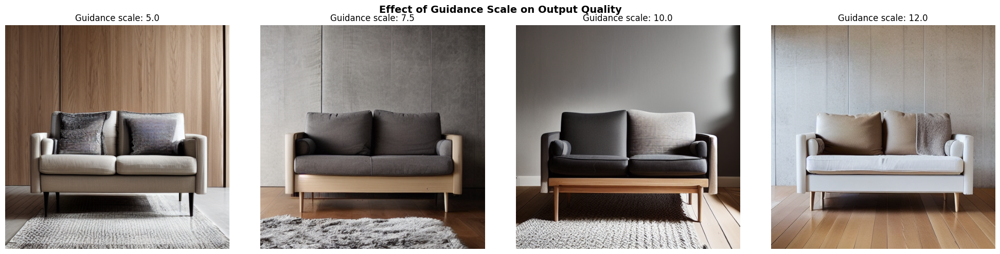

Saved!


In [30]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (ax, result, gs) in enumerate(
        zip(axes, guidance_results, guidance_scales)):
    ax.imshow(result)
    ax.set_title(f"Guidance scale: {gs}", fontsize=12)
    ax.axis("off")

plt.suptitle("Effect of Guidance Scale on Output Quality",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("guidance_scale_comparison.png")
plt.show()
print("Saved!")

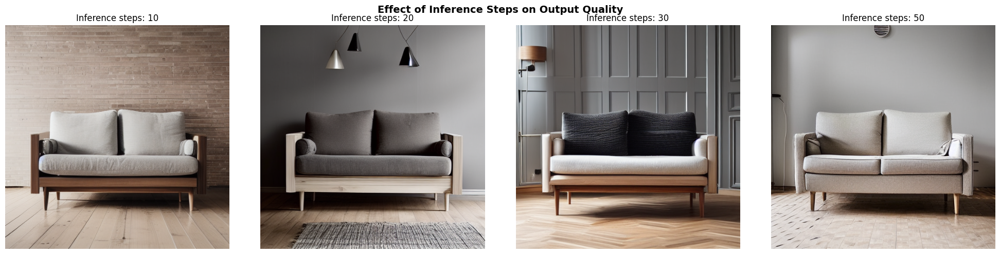

Saved!


In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (ax, result, steps) in enumerate(
        zip(axes, steps_results, inference_steps)):
    ax.imshow(result)
    ax.set_title(f"Inference steps: {steps}", fontsize=12)
    ax.axis("off")

plt.suptitle("Effect of Inference Steps on Output Quality",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("inference_steps_comparison.png")
plt.show()
print("Saved!")

In [1]:
!pip install flask pyngrok

from pyngrok import ngrok
from flask import Flask, request, send_file
from PIL import Image
import io
import threading

ngrok.set_auth_token("3CCYurDubeOH6njtLkr8VZAkAgV_6nbQyL1ZUncA3hWVTe5u4")

app_flask = Flask(__name__)

@app_flask.route("/generate", methods=["POST"])
def generate():
    try:
        file = request.files["file"]
        
        # Custom prompt takes priority over base_prompt
        custom_prompt = request.form.get("custom_prompt", None)
        base_prompt = request.form.get(
            "base_prompt",
            "a modern scandinavian living room, \
             warm lighting, minimalist furniture, photorealistic"
        )
        
        final_prompt = custom_prompt if custom_prompt else base_prompt
        
        click_x = request.form.get("click_x", None)
        click_y = request.form.get("click_y", None)
        user_id = request.form.get("user_id", "default")

        image = Image.open(file.stream).convert("RGB")
        click_point = [int(click_x), int(click_y)] \
                      if click_x and click_y else None

        result = full_pipeline(
            input_image=image,
            user_id=user_id,
            click_point=click_point,
            base_prompt=final_prompt
        )

        buf = io.BytesIO()
        result.save(buf, format="JPEG")
        buf.seek(0)
        return send_file(buf, mimetype="image/jpeg")

    except Exception as e:
        return {"error": str(e)}, 500

public_url = ngrok.connect(5000)
print("NGROK URL:", public_url)
print("Share this URL with Person 2!")

threading.Thread(
    target=lambda: app_flask.run(port=5000, use_reloader=False)
).start()

NGROK URL: NgrokTunnel: "https://wackiness-spoils-manhunt.ngrok-free.dev" -> "http://localhost:5000"
Share this URL with Person 2!
